In [1]:
!pip install opencv-python

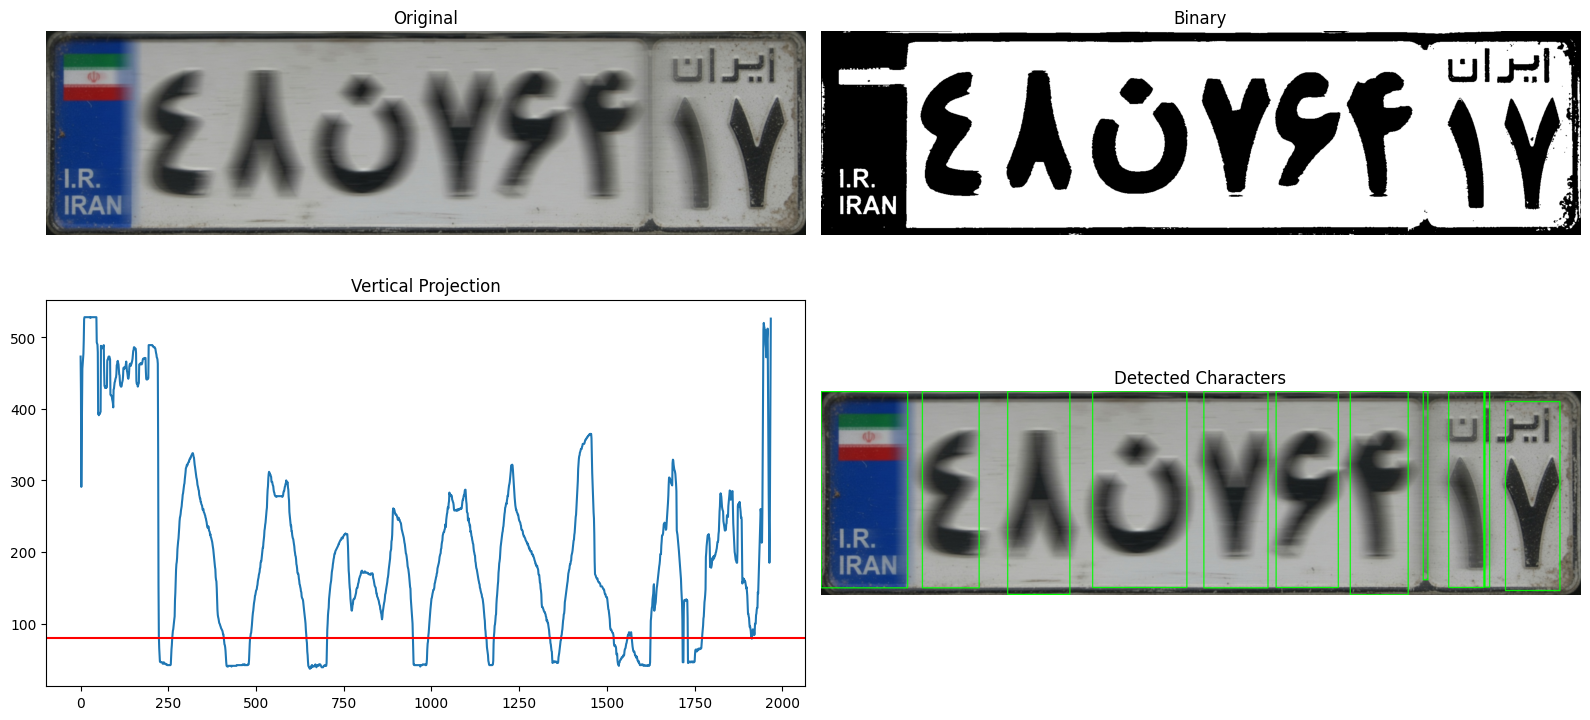

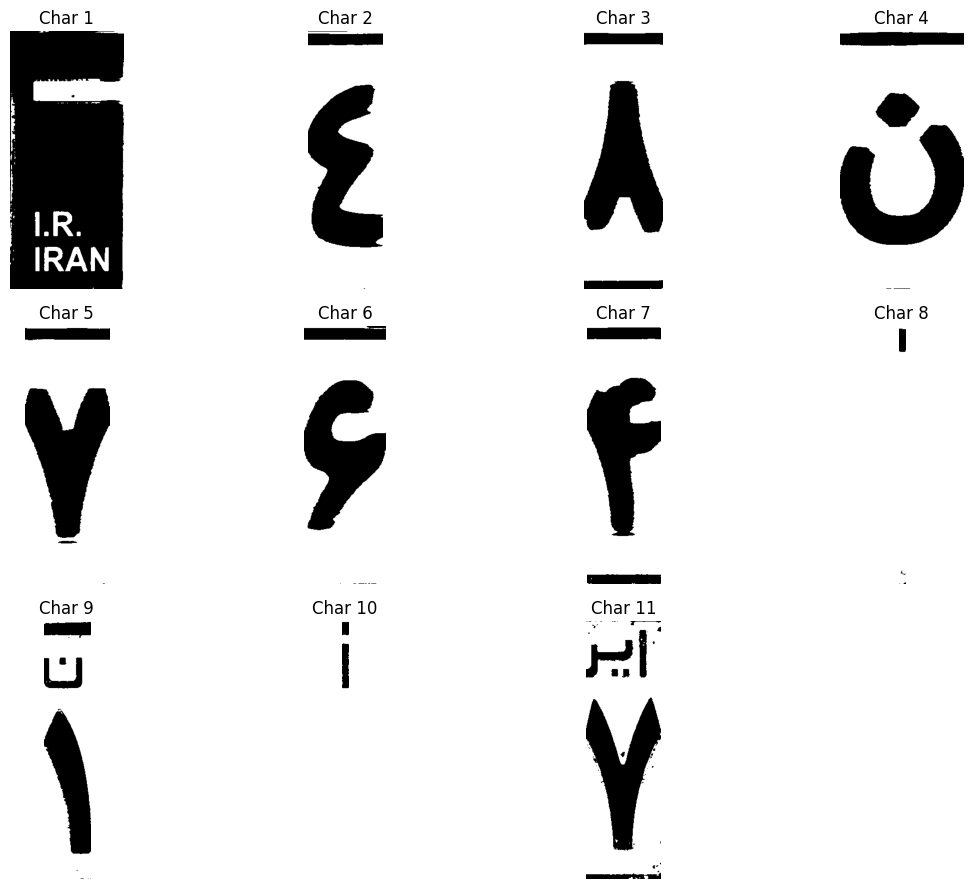

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/Github/Iran-License-Plate-Reader/image.jpg"

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary_inv = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

binary_show = cv2.bitwise_not(binary_inv)

kernel = np.ones((3,3), np.uint8)
binary = cv2.morphologyEx(binary_show, cv2.MORPH_OPEN, kernel)

projection = np.sum(binary_inv > 0, axis=0)

threshold = projection.max() * 0.15

regions = []
inside = False

for x, value in enumerate(projection):

    if value > threshold and not inside:
        start = x
        inside = True

    elif value <= threshold and inside:
        end = x

        if end - start > 5:
            regions.append((start, end))

        inside = False

result = img.copy()
characters = []

for start, end in regions:

    ys, xs = np.where(binary[:, start:end] > 0)

    if len(ys) == 0:
        continue

    y1 = ys.min()
    y2 = ys.max()

    x1 = start
    x2 = end

    cv2.rectangle(result, (x1,y1), (x2,y2), (0,255,0), 2)

    characters.append(binary_show[y1:y2, x1:x2])

plt.figure(figsize=(16,8))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(binary_show, cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.subplot(2,2,3)
plt.plot(projection)
plt.axhline(threshold, color="red")
plt.title("Vertical Projection")

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Characters")
plt.axis("off")

plt.tight_layout()
plt.show()

cols = 4
rows = int(np.ceil(len(characters)/cols))

plt.figure(figsize=(12,3*rows))

for i,char in enumerate(characters):
    plt.subplot(rows, cols, i+1)
    plt.imshow(char, cmap="gray")
    plt.title(f"Char {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

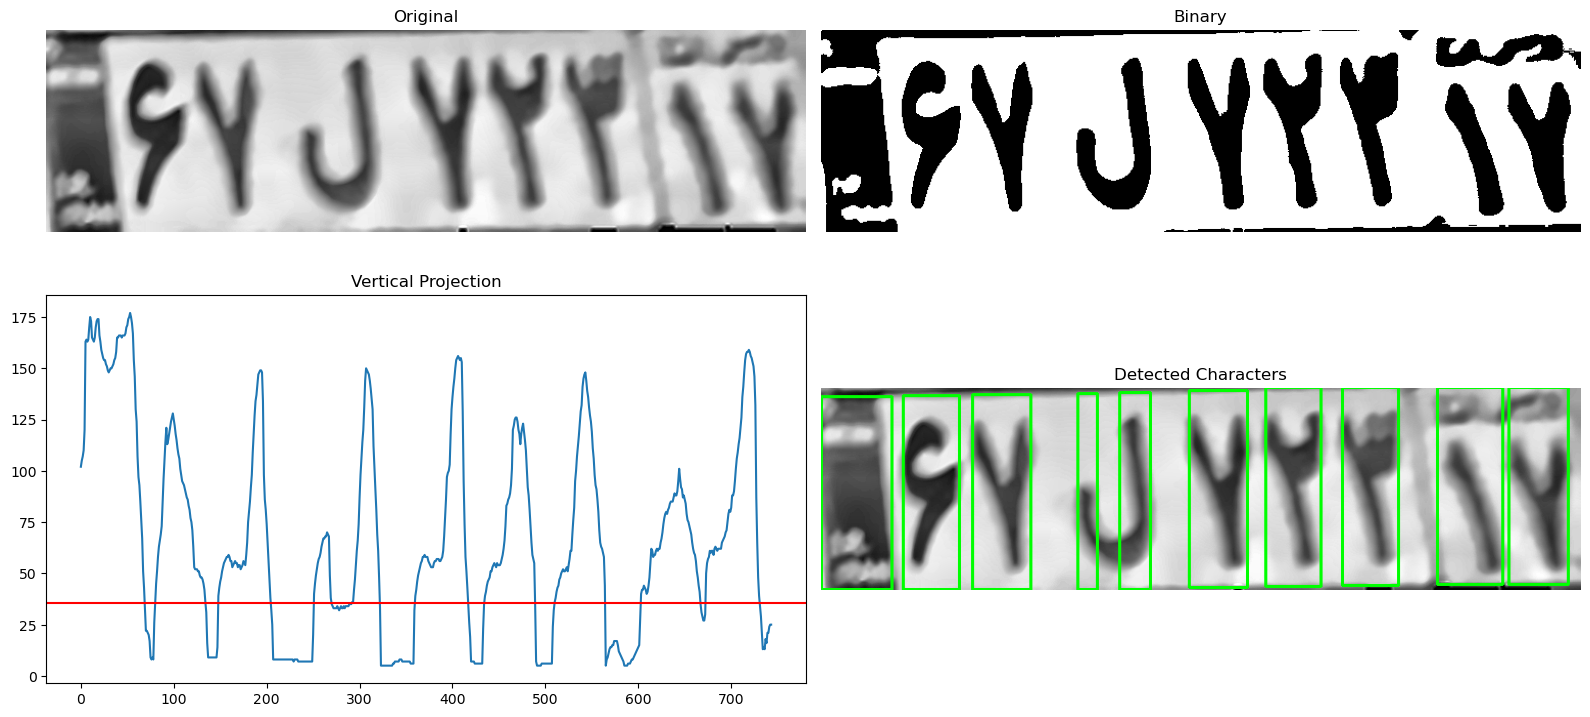

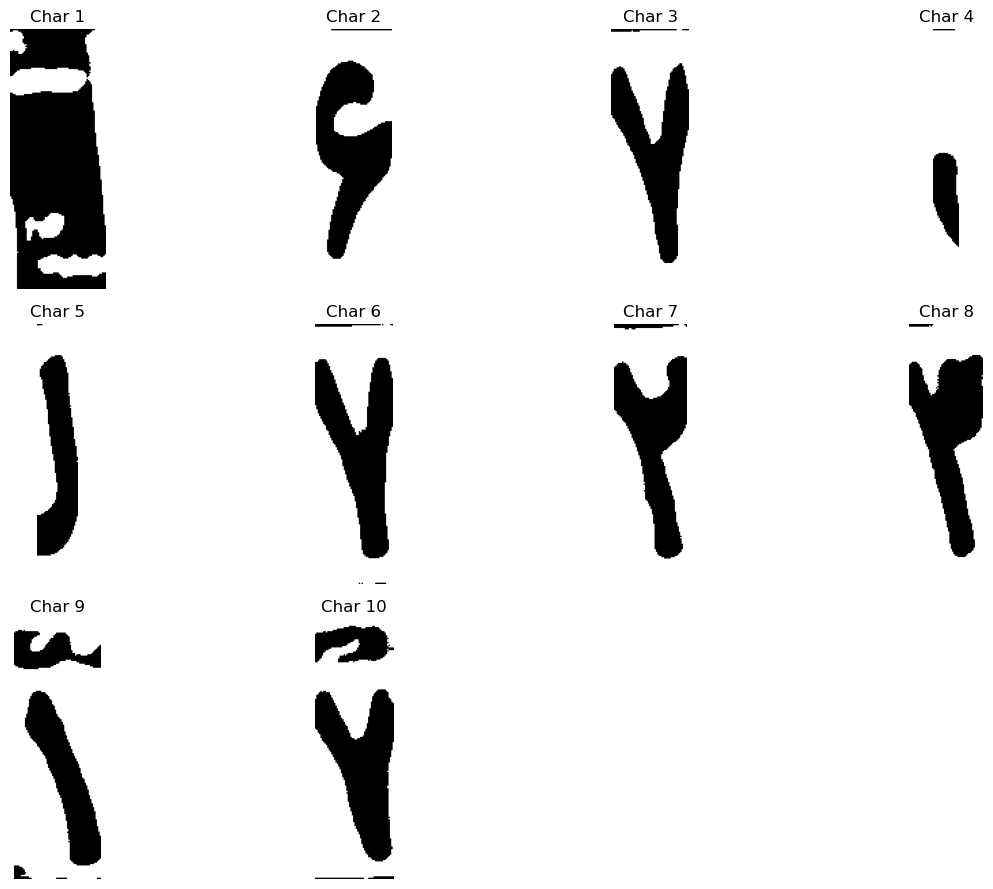

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/home/ashkan/Desktop/Github/Iran-License-Plate-Reader/mask_crop/338_png.rf.536d13ab8e710ce92b5d2288e7b3f7d4_0.png"

img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary_inv = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

binary_show = cv2.bitwise_not(binary_inv)

kernel = np.ones((3,3), np.uint8)
binary = cv2.morphologyEx(binary_show, cv2.MORPH_OPEN, kernel)

projection = np.sum(binary_inv > 0, axis=0)

threshold = projection.max() * 0.20

regions = []
inside = False

for x, value in enumerate(projection):

    if value > threshold and not inside:
        start = x
        inside = True

    elif value <= threshold and inside:
        end = x

        if end - start > 5:
            regions.append((start, end))

        inside = False

result = img.copy()
characters = []

for start, end in regions:

    ys, xs = np.where(binary[:, start:end] > 0)

    if len(ys) == 0:
        continue

    y1 = ys.min()
    y2 = ys.max()

    x1 = start
    x2 = end

    cv2.rectangle(result, (x1,y1), (x2,y2), (0,255,0), 2)

    characters.append(binary_show[y1:y2, x1:x2])

plt.figure(figsize=(16,8))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(binary_show, cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.subplot(2,2,3)
plt.plot(projection)
plt.axhline(threshold, color="red")
plt.title("Vertical Projection")

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Characters")
plt.axis("off")

plt.tight_layout()
plt.show()

cols = 4
rows = int(np.ceil(len(characters)/cols))

plt.figure(figsize=(12,3*rows))

for i,char in enumerate(characters):
    plt.subplot(rows, cols, i+1)
    plt.imshow(char, cmap="gray")
    plt.title(f"Char {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()